## 4.5 极大投影设计

极大极小设计侧重于填充$p$维空间,但前文可见,这类设计在低维子空间上的投影效果可能较差.我们尝试通过将极大极小设计限定在拉丁超立方设计范畴内来解决该问题,以此保证优良的一维投影性质.然而极大极小拉丁超立方设计在$2,\dots,p-1$维子空间上的投影仍有可能不理想.德拉古利奇等人(2012)尝试在所有可能子空间上计算式(4.18)中的总倒数距离准则,以此改善极大极小拉丁超立方设计的投影特性.全部子空间数量为$p+\binom{p}{2}+\cdots+\binom{p}{p-1}=2^{p}-2$;当维度$p$较大时,子空间总数十分庞大,使得基于该总倒数距离准则的优化计算难以实现.

该问题还有另一种构建思路:为各个变量引入权重,并将准则修改为

$$\mathrm{TRD}_{w}(D)=\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\left(\sum_{k=1}^{p}w_{k}(x_{ik}-x_{jk})^{2}\right)^{\alpha}}$$

其中$w_{i}\ge0$,$i=1,\dots,p$,且$\sum_{i=1}^{p}w_{i}=1$.例如,若已知$x_{1}$和$x_{2}$为重要变量,则可取$w_{1}=w_{2}=1/2$,其余权重全部置为$0$.但难点在于,试验设计阶段无法预先判断哪些变量具备重要作用.一种可行解决思路是采用贝叶斯方法:为权重向量$\boldsymbol{w}=(w_{1},\dots,w_{p-1})'$指定先验分布,再对所有可能的$\boldsymbol{w}$取值求$\mathrm{TRD}_{w}(D)$的均值.

假设我们没有关于变量重要性的任何先验信息,则应当对权重向量$\boldsymbol{w}$设置均匀先验分布:

$$f(\boldsymbol{w})=(p-1)!,\;\text{其中}\;\;\boldsymbol{w}\in\mathcal{W}=\{\boldsymbol{w}:\boldsymbol{w}>0,\sum_{i=1}^{p-1}w_{i}\le1\}\tag{4.22}$$

于是有

$$\int_{\mathcal{W}}\mathrm{TRD}_{w}(D)f(\boldsymbol{w})\mathrm{d}\boldsymbol{w}=\sum_{i=1}^{n}\sum_{j\ne i}\int_{\mathcal{W}}\frac{1}{\left(\sum_{k=1}^{p}w_{k}(x_{ik}-x_{jk})^{2}\right)^{\alpha}}f(\boldsymbol{w})\mathrm{d}\boldsymbol{w}$$

高维积分同样会带来高昂的计算成本.但可以注意到,当$\alpha=p=2$时能够得到显式解:

$$\int_{0}^{1}\frac{1}{(w_{1}(x_{i1}-x_{j1})^{2}+(1-w_{1})(x_{i2}-x_{j2})^{2})^{2}}\mathrm{d}w_{1}=\frac{1}{(x_{i1}-x_{j1})^{2}(x_{i2}-x_{j2})^{2}}$$

利用数学归纳法可以证明下述结论(约瑟夫等人,2015).

>**定理4.3** 若$\alpha=p$,则在式(4.22)给出的先验分布下,有$$\int_{\mathcal{W}}\frac{1}{\left(\sum_{k=1}^{p}w_{k}(x_{ik}-x_{jk})^{2}\right)^{\alpha}}f(\boldsymbol{w})\mathrm{d}\boldsymbol{w}=\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}$$

由此,设计准则化为

$$\min_{D}\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\tag{4.23}$$

该准则能够最大化设计的投影能力,因此约瑟夫等人(2015)将基于此准则构造的设计称为最大投影(MaxPro)设计.该准则的计算开销并不高于式(4.18)中的总倒数距离准则,只是将分母中的求和项替换为乘积项.乘积项保证任意两个采样点不会在任一坐标上取值相同,因此该准则会自动满足拉丁超立方设计的约束条件.

最大投影准则还可通过下述方式解释.假设采用式(2.11)中的各向异性高斯相关函数,并对相关参数设置无信息先验:$f(\theta_{k})\propto1/\theta_{k}^{3}$,$k=1,\dots,p$,则

$$\begin{align*}\mathbb{E}[\|\boldsymbol{R}-\boldsymbol{I}_{n}\|_{1}]&\propto\sum_{i=1}^{n}\sum_{j\ne i}\int\exp\left(-\sum_{k=1}^{p}\frac{(x_{ik}-x_{jk})^{2}}{\theta_{k}^{2}}\right)\prod_{k=1}^{p}\frac{1}{\theta_{k}^{3}}\mathrm{d}\boldsymbol{\theta}\tag{4.24}\\&=\sum_{i=1}^{n}\sum_{j\ne i}\prod_{k=1}^{p}\int\exp\left(-\frac{(x_{ik}-x_{jk})^{2}}{\theta_{k}^{2}}\right)\frac{1}{\theta_{k}^{3}}\mathrm{d}\theta_{k}\\&\propto\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\end{align*}$$

由此可见,各向同性高斯相关函数对应极大极小准则;而对长度尺度赋予无信息先验的各向异性高斯相关函数,则导出最大投影准则.分母中的乘积项并非严格意义上的距离度量,但可看作闵可夫斯基距离的极限形式(约瑟夫等人,2019):

$$\lim_{\alpha\to0}\frac{\|\boldsymbol{x}_{i}-\boldsymbol{x}_{j}\|_{\alpha}}{p^{1/\alpha}}=\left(\prod_{k=1}^{p}|x_{ik}-x_{jk}|\right)^{1/p}\tag{4.25}$$

换言之,若选取较小的$\alpha$,基于闵可夫斯基距离并利用式(4.16)构造极大极小设计,所得设计将与最大投影设计十分接近.

最大投影设计还可借助乘积形式的有理二次核进行推导:

$$R(\boldsymbol{\Delta})=\prod_{k=1}^{p}\left(1+\frac{\Delta_{k}^{2}}{\theta_{k}^{2}}\right)^{-1}\tag{4.26}$$

于是

$$\begin{align*}\|\boldsymbol{R}-\boldsymbol{I}_{n}\|_{1}&=\sum_{i=1}^{n}\sum_{j\ne i}\prod_{k=1}^{p}\left(1+\frac{(x_{ik}-x_{jk})^{2}}{\theta_{k}^{2}}\right)^{-1}\\&=\prod_{k=1}^{p}\theta_{k}^{2p}\sum_{i=1}^{n}\sum_{j\ne i}\prod_{k=1}^{p}\frac{1}{\theta_{k}^{2}+(x_{ik}-x_{jk})^{2}}\\&\le\prod_{k=1}^{p}\theta_{k}^{2p}\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\sum_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\end{align*}$$

对任意$\boldsymbol{\theta}$,该式均可由最大投影设计实现最小化.

约瑟夫等人(2015)提出采用基于梯度的优化方法构造最大投影设计,式(4.23)目标函数的梯度表达式为

$$\frac{\partial}{\partial x_{rs}}\left(\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\right)=4\sum_{i\ne r}\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}\frac{1}{(x_{is}-x_{rs})}$$

但该目标函数存在大量局部最优解,想要找到全局最优通常需要设置大量随机初始点.为避免多次随机初始化,他们借鉴莫里斯与米切尔(1995)的思路,先通过模拟退火算法搜寻最大投影拉丁超立方设计,再执行梯度优化.R语言程序包`MaxPro`实现了该算法(巴,约瑟夫,2018).`SFDesign`程序包(王,约瑟夫,2025c)采用相近策略,并在模拟退火阶段之后追加一轮确定性优化,能够进一步提升设计效果.图4.10展示了$p=2$,$n=7$与$n=20$对应的最大投影设计.可以观察到,这类设计具备优良的空间填充特性且满足拉丁超立方结构;但各坐标轴上的采样点并不像标准拉丁超立方设计那样等间距分布.采样点会向区域边界偏移,不过偏移程度低于图4.9中经过切比雪夫变换的设计.

>**图4.10** 二维($p=2$)MaxPro设计,左图样本量$n=7$,右图样本量$n=20$

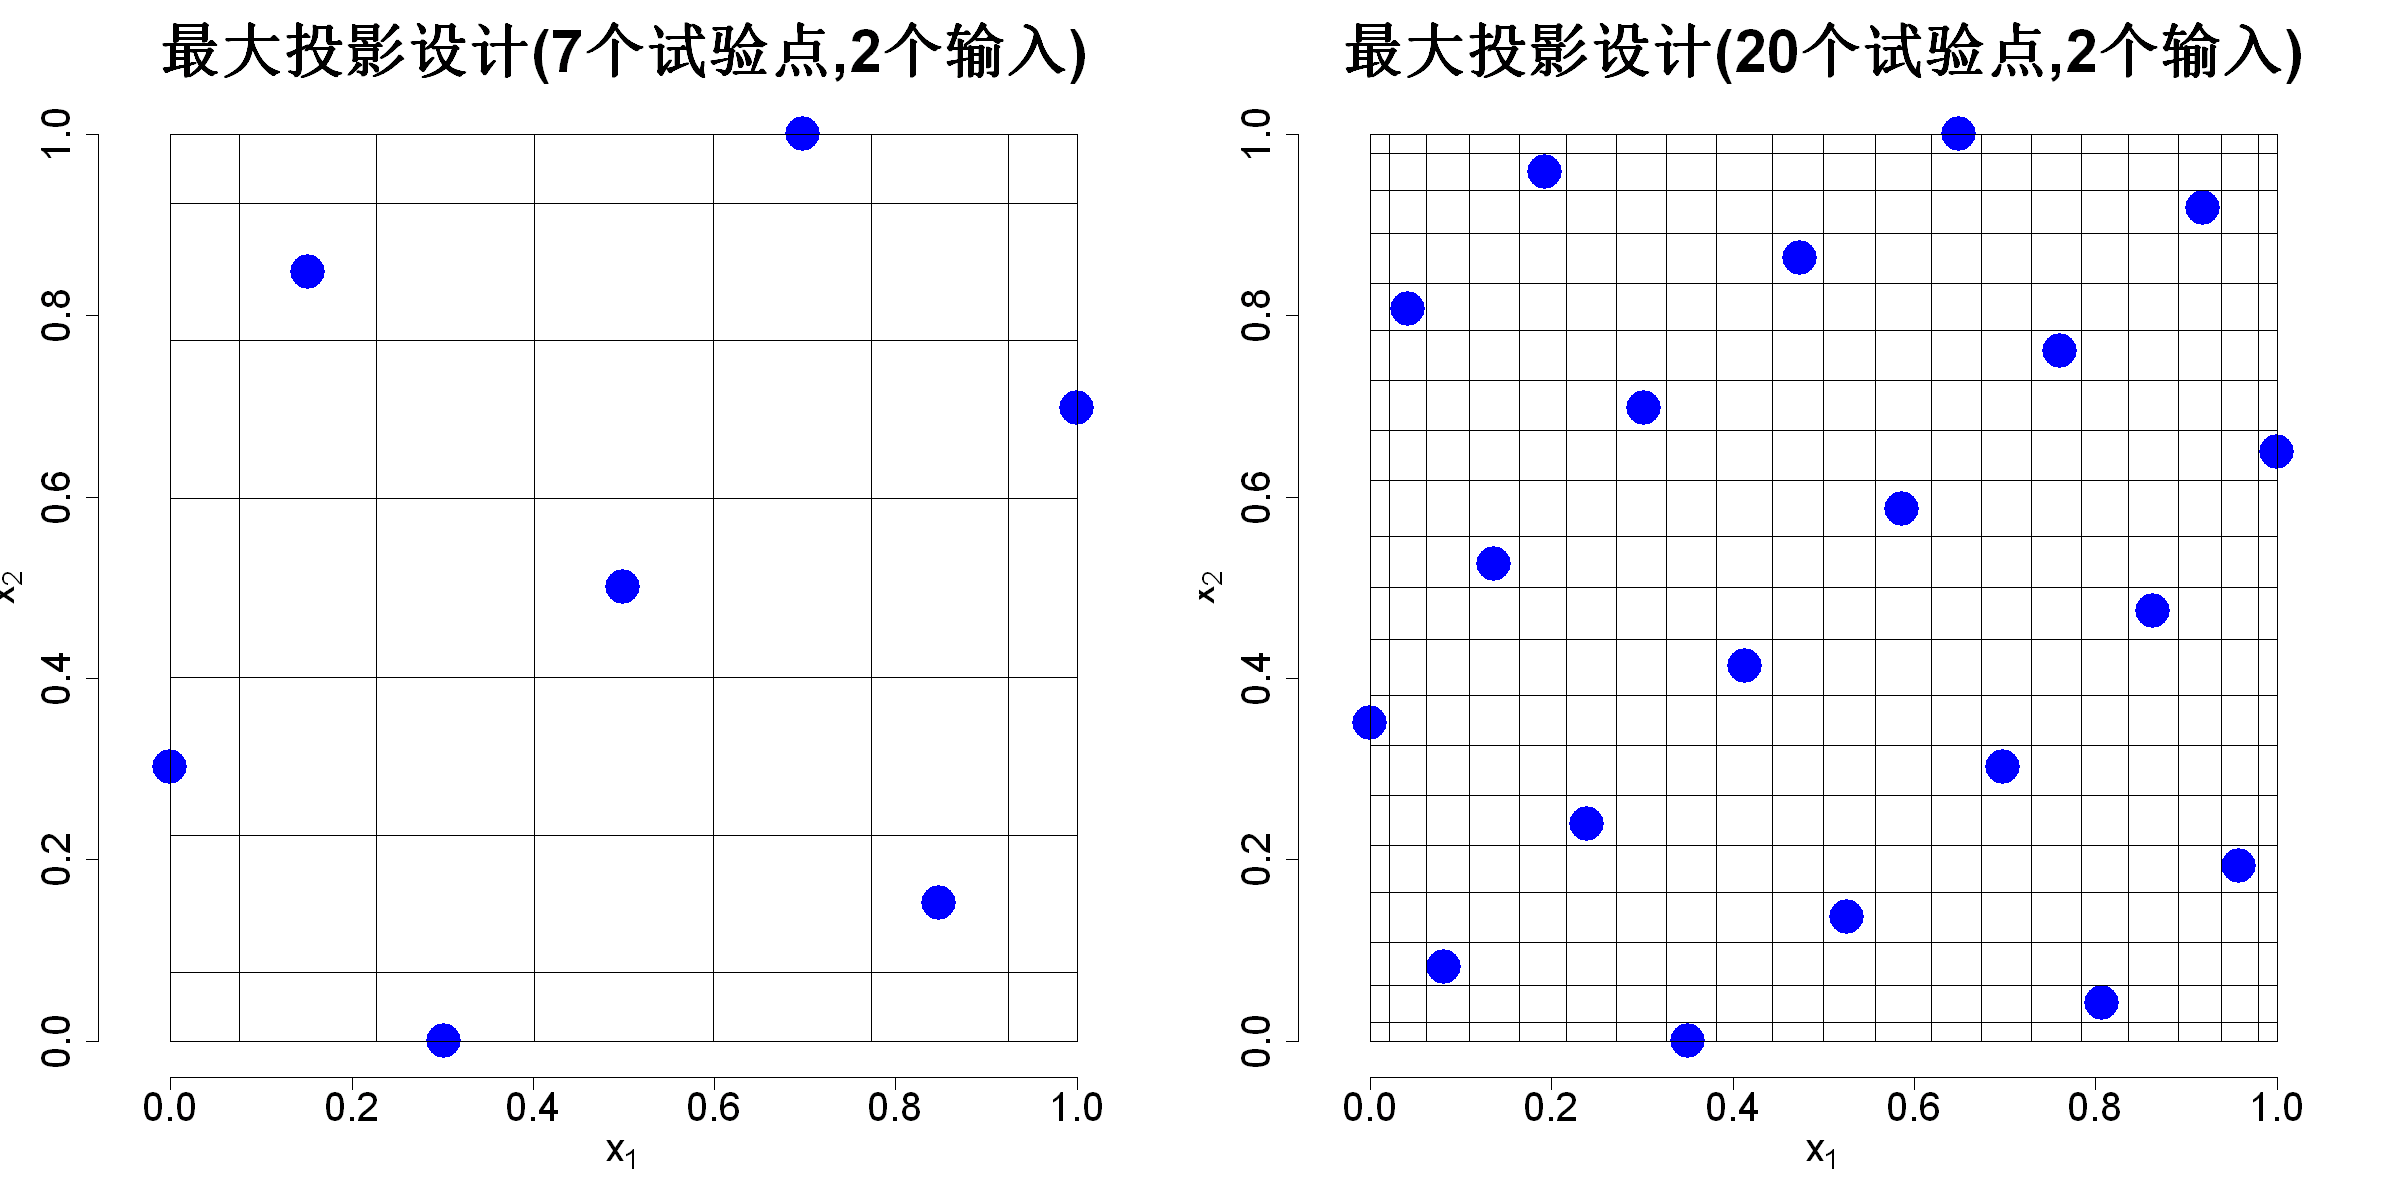

In [2]:
#图4.10

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
set.seed(10)
library(MaxPro)
D=MaxPro(MaxProLHD(n,p)$Design)$Design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计(7个试验点,2个输入)",cex.main=3,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}

set.seed(10)
library(SFDesign)
p=2;n=20
D=maxpro.optim(maxproLHD(n,p)$design)$design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计(20个试验点,2个输入)",cex.main=3,asp=1)
d1=sort(D[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))

高维设计难以直接可视化.为此,图4.11以散点图矩阵形式展示一个5维,$n=50$的最大投影设计各采样点的二维投影.能够看出,采样点在各类二维投影中分布均匀舒展.图4.12对比了最大投影设计与极大极小拉丁超立方设计:分别绘制二者在1维,2维,3维,4维子空间投影以及完整高维空间内,采样点间最小距离的下界.可见在完整高维空间中,极大极小拉丁超立方设计拥有更大的最小距离,这一点符合预期,因为该设计正是以最大化全空间最小距离为目标构造得到.但当采样点投影至2维,3维或4维子空间时,最大投影设计具备更大的最小距离.该特性十分关键,因为开展试验前无法预知有多少变量是重要变量.最大投影设计在一维投影上的最小距离小于极大极小拉丁超立方设计,原因在于最大投影设计有更多采样点靠近区域边界.总体而言,最大投影设计通常在$2,\dots,p-1$维投影上表现优于极大极小拉丁超立方设计,因此能够更好地应对变量重要性未知带来的不确定性.

>**图4.11** $n=50$,$p=5$的最大投影设计采样点散点图矩阵

In [5]:
#图4.11

options(repr.plot.width=10,repr.plot.height=10)
p=5;n=50
set.seed(2)
library(SFDesign)
D=maxpro.optim(maxproLHD(n,p)$design)$design
library(car)
scatterplotMatrix(D,diagonal=list(method="histogram"),smooth=FALSE,regLine=FALSE,pch=16)

>**图4.12** 采样点投影至子空间后各点间最小距离的下界

In [9]:
#图4.12

options(repr.plot.width=10,repr.plot.height=10)
p=5;n=50
set.seed(2)
library(SFDesign)
library(gtools)
D1=maximinLHD(n,p)$design
set.seed(2)
D2=maxpro.optim(maxproLHD(n,p)$design)$design

min_mindist=function(M){
    n=nrow(M)
    p=ncol(M)
    a=rep(0,p)
    for(j in 1:p){
        comb=combinations(p,j)
        k=nrow(comb)
        temp=rep(0,k)
        for(i in 1:k)temp[i]=min(dist(M[,comb[i,]]))
        a[j]=min(temp)
    }
    return(a)
}

d1=min_mindist(D1)
d2=min_mindist(D2)
matplot(1:p,cbind(d1,d2),type="b",pch=c(4,1),col=c(2,4),lty=c(2,1),bty="n",xlim=c(1,5),ylim=c(0,0.5),xlab="projectiondimension",ylab="minimumofminimumdistances",cex=2,cex.lab=2,cex.axis=2,lwd=3)
legend(1,.5,c("最大投影设计","极大极小拉丁超立方设计"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2),cex=2)

张等人(2021)发现小规模极大极小设计(较小的$n^{1/p}$)不利于估计相关参数,该现象源于极大极小设计投影特性较差.图4.13展示6维,64次试验的极大极小设计采样点两两距离的直方图.由于$64<2^{6}$,所有采样点被推向超立方体$[0,1]^6$的顶点,仅存在少数几种互不相同的两两距离.图中同时给出64次试验的最大投影设计对应的两两距离分布,可以观察到距离取值近似连续,能够通过形状参数为10.1与12.7的缩放贝塔分布良好拟合.张等人(2021)通过数值试验发现,若设计的两两距离近似服从贝塔分布,则在相关参数估计方面表现优异.为此他们提出优化算法,用以生成两两距离分布贴近贝塔分布的设计,贝塔分布的形状参数根据$n$和$p$选取.尽管最大投影设计最初以预测性能为目标构建,但这类设计恰好具备两两距离服从贝塔分布的特性,因此可以预期其在相关参数估计任务中同样拥有良好表现.

shape1   shape2 
10.08950 12.72548

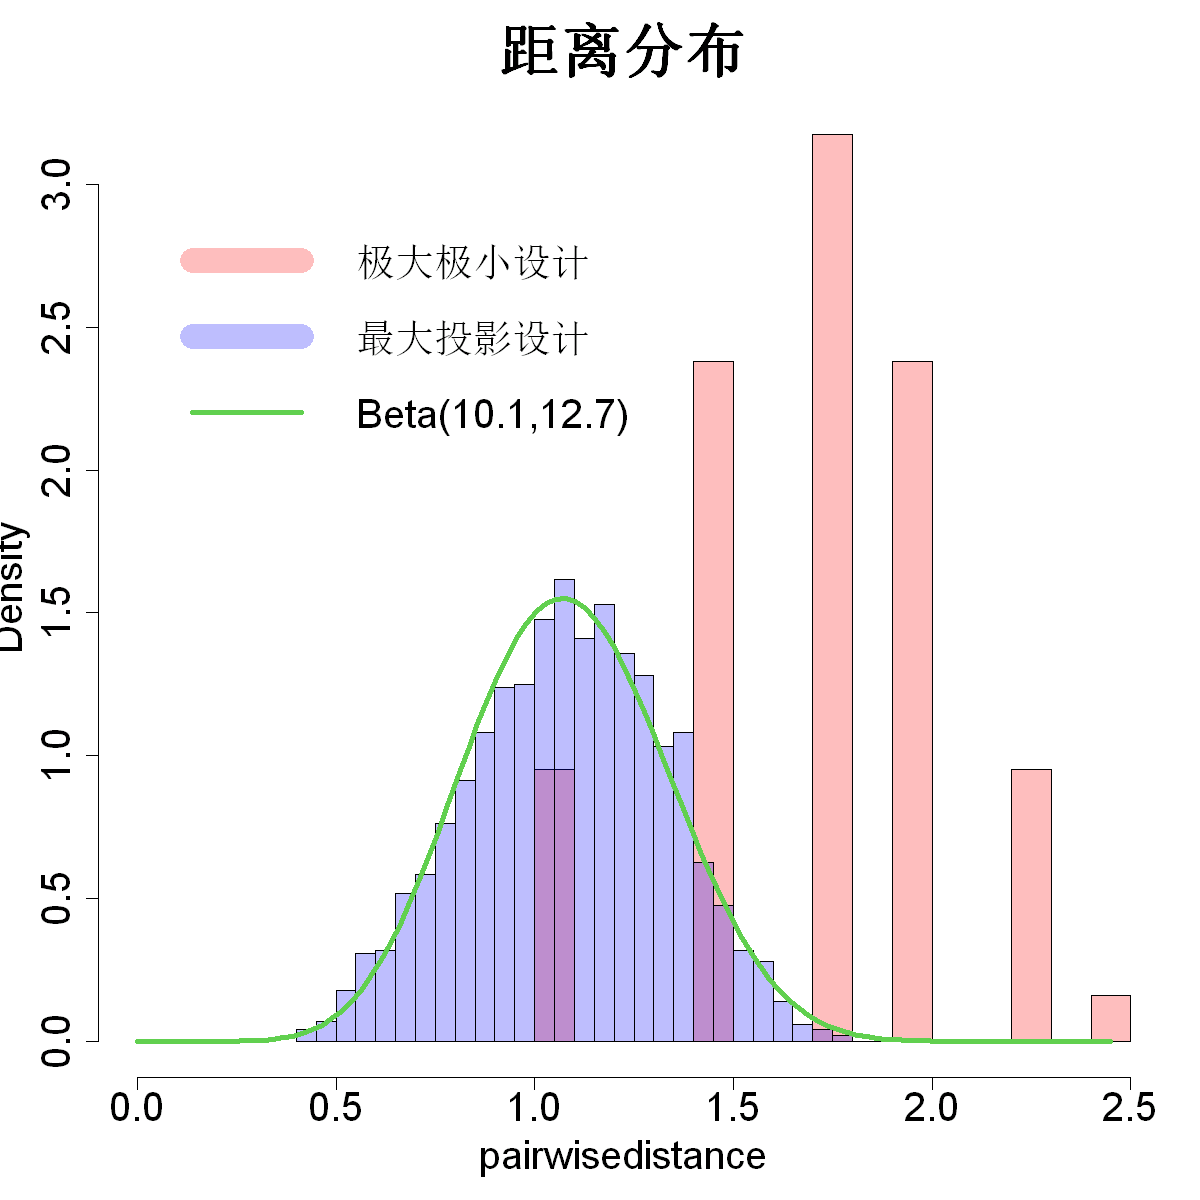

In [11]:
#图4.13

options(repr.plot.width=10,repr.plot.height=10)
p=6;n=64
set.seed(1)
library(SFDesign)
D1=maximin.optim(maximinLHD(n,p)$design,find.best.ini=TRUE)$design
D2=maxpro.optim(maxproLHD(n,p)$design)$design
d1=c(dist(D1))
d2=c(dist(D2))
library(fitdistrplus)
a=fitdist(d2/sqrt(p),"beta")
a$estimate
hist(d1,prob=TRUE,xlim=c(0,sqrt(p)),col=rgb(1,0,0,1/4),xlab="pairwisedistance",main="距离分布",cex.lab=2,cex.axis=2,cex.main=3)
hist(d2,prob=TRUE,col=rgb(0,0,1,1/4),breaks=30,add=TRUE)
curve(dbeta(x/sqrt(p),a$estimate[1],a$estimate[2])/sqrt(p),from=0,to=sqrt(p),add=TRUE,col=3,lwd=4)
legend(0,3,legend=c("极大极小设计","最大投影设计","Beta(10.1,12.7)"),col=c(rgb(1,0,0,1/4),rgb(0,0,1,1/4),3),lty=c(1,1,1),lwd=c(20,20,4),bty="n",cex=2)

相较于极大极小拉丁超立方设计,最大投影设计的一大突出优势在于:最大投影准则支持序贯构造.我们可先选定初始点$\boldsymbol{x}_{1}\in\mathcal{X}$,随后依次逐个添加$\boldsymbol{x}_{2},\dots,\boldsymbol{x}_{n}$(约瑟夫,2016):

$$\boldsymbol{x}_{k+1}=\argmin_{\boldsymbol{x}\in\mathcal{X}}\sum_{i=1}^{k}\frac{1}{\prod_{j=1}^{p}(x_{j}-x_{ij})^2},\;k=1,\dots,n-1\tag{4.27}$$

R语言`MaxPro`包中的`MaxProAugment`函数实现了该构造方式(巴,约瑟夫,2018).这种贪心优化得到的设计,性能不及采用模拟退火结合梯度优化构造的设计,但它具备高度灵活性,能够处理多种不同类型的问题.

式(4.27)序贯构造最大投影设计的一类应用场景,是生成验证集以检验拟合模型的优劣.举例来说,选取仿真试验虚拟库中的二维布兰宁函数(苏尔亚诺维奇,宾厄姆,2013):

$$f(\boldsymbol{x})=\left(x_{2}-\frac{5.1}{4\pi^{2}}x_{1}^{2}+\frac{5}{\pi}x_{1}-6\right)^{2}+10\left(1-\frac{1}{8\pi}\right)\cos(x_{1})+10,\;x_{1}\in[-5,10],\;x_{2}\in[0,15]\tag{4.28}$$

将定义域缩放至$[0,1]^2$后的函数图像如图4.14左图所示,图中蓝色圆点为一组10个样本点构成的最大投影设计.接下来利用式(4.27)额外生成10个点作为验证集,对应图中的红色三角标记.本文借助R语言`rkriging`程序包拟合普通克里金预测模型(黄,约瑟夫,2024),并在验证集上计算预测均方根误差(RMSE).作为对比,随机生成100组规模为10的验证集并分别计算RMSE,结果由图4.14右图的箱线图展示.可以发现,序贯最大投影验证集对应的RMSE高于箱线图上须.原因在于随机验证集容易包含靠近原始设计点的样本,这类位置易于预测,因此得到偏小的RMSE;而序贯最大投影生成的验证点在全部子空间上均远离原始设计点,由此构成一套更难预测的验证集.

>**图4.14** 左图为布兰宁函数热力图,叠加绘制最大投影设计(蓝色圆点)以及采用序贯最大投影方法生成的验证点(红色三角形).右图为100组随机验证集对应的均方根误差箱线图

In [7]:
#图4.14

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
branin=function(x)
{
x1=x[1]*15-5
x2=x[2]*15
(x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2+10*(1-1/(8*pi))*cos(x1)+10
}
p=2;n=10
set.seed(123)
library(MaxPro)
D=MaxPro(MaxProLHD(n,p)$Design)$Design
y=apply(D,1,branin)
A=MaxProAugment(ExistDesign=D,CandDesign=CandPoints(N=10000,2),nNew=10)$Design[(n+1):20,]
true=apply(A,1,branin)
library(rkriging)
a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,A)$mean
rmse0=sqrt(mean((pred-true)^2))

N.plot=250
p1=seq(0,1,length=N.plot)
p2=seq(0,1,length=N.plot)
fc=matrix(0,N.plot,N.plot)
for(i in 1:N.plot)
{
for(j in 1:N.plot)
fc[i,j]=branin(c(p1[i],p2[j]))
}

library(fields)
imagePlot(p1,p2,fc,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(12,rev=TRUE),main="验证点",cex.main=3,cex.lab=2,cex.axis=2)
points(D,pch=16,col="blue",cex=3)
points(A,pch=2,col="darkred",lwd=4,cex=3)

rmse=rep(0,100)
for(i in 1:100)
{
u=matrix(runif(p*10),nrow=10,ncol=p)
pred=Predict.Kriging(a,u)$mean
true=apply(u,1,branin)
rmse[i]=sqrt(mean((pred-true)^2))
}
boxplot(rmse,main="RMSE",cex.main=3,cex.axis=2)
abline(h=rmse0,col="darkred",lwd=3)
text(.75,rmse0+2,"sequentialMaxPro",cex=2)
par(mfrow=c(1,1))